## <b>Регрессионный анализ. Линейная,  полиномиальная регрессия.</b>


<p style="align: center;"><img align=center src="https://sun9-3.userapi.com/impg/rMxsV1l3x_NgXZnO2BR_Z_vQ5CMfAysGMkpVrg/5vII3kSwywk.jpg?size=1233x403&quality=96&proxy=1&sign=607ece16ae211ad91d8c9a1ba285c822&type=album"  width=900></p>
<div class="alert alert-info">
    <h2>Некоторые важные определения</h2>
<ul>
 <li><b>Классификация</b> - задача о разделении классов, по заданному набору признаков.</li>
 <li><b>Регрессия</b> - задача о предсказывании конкретного значения, но основе заданных параметров.</li>
 <li><b>Кластеризация</b>  - задача об объединении объектов в группы по каким-то уникальным общим свойствам/на основе каких-то закономерностях данных.</li>

</ul>
</div>

### Линейная регрессия
<p id="1">Сегодня мы детально обсудим очень важный класс моделей машинного обучения – линейных. На данный момент развития машинного обучения и искусственного интелекта в целом можно строить довольно сложные модели, нейросети, но практически везде в основе лежат линейные модели. Они имеют большое кол-во преимуществ, например, такие как относительная простота вычислений и интепретация результатов, эффективность для описания многих процессов. Линейные модели используются в прогнозе цен, построении вероятностных моделей в кредитном скоринге, трейдинге, и т.д. </p>

Линейные модели описываются довольно простым линейным уравнением, где $y$ - целевая переменная, $w$ - вектор весов модели, $X$ - матрица наблюдений,  а $e$ - ошибка.$$y_i = \sum\limits^{m}_{j=1}w_j X_{ij} + e_i$$


<p style="align: center;"><img align=center src="https://wiki.loginom.ru/images/linear-regression.svg"  width=900></p>


\begin{equation}
Y_i = \beta_0 + \sum_{j=1}^k \beta_j X_{ij} + \epsilon_i
\end{equation}

<div class="alert alert-info"><i>В каких случаях мы можем использовать линейную регресию? Какие данные мы можем использовать?</i>

Требования к данным.
<ol><li>Линейная зависимость целевой переменной</li><li>Нормальное распределение остатков</li><li>Постоянная изменчивость остатков. Гомоскедастиность.</li></ol>

</div>

<ol><b><li><b>Линейная зависимость целевой переменной</b></li></b> Линейная модель не сможет описвать сложные кривые и нелинейные данные. Должно быть хотя бы подозрение на линейность модели.<p style="align: center;"><img align=center src="https://sun9-35.userapi.com/impg/hP4Ue_r14n4_zs8d0UKA7LpZx74vPQDJy9Igqg/ve5O14Ggors.jpg?size=885x305&quality=96&proxy=1&sign=de7b6f1424868593e0970a3887ea4660&type=album"  width=900></p>
<b><li>Нормальное распределение остатков</li></b> Величины остатков, должны быть близки к нормальному распределению. Иначе, наша модель будет делать предсказание со смещением.<p style="align: center;"><img align=center src="https://sun9-7.userapi.com/impg/g-SaD6uQxQWVwJAXUC1RaH_NwOxIw0o0cpoD3Q/iMp5_Nqc82U.jpg?size=1207x400&quality=96&proxy=1&sign=865580edacb008724e7bc9d0c388a12d&type=album"  width=900></p><p style="align: center;"></p>
<b><li>Постоянная изменчивость остатков. Гомоскедастиность.</li></b>Если у данных есть четко выраженная постоянная изменичивость остатков на каком-то отрезке и нет случайности нормального распределения, то такие данные не будут эффективно описаны линейной регрессией. Пример гетероскедастичной последовательности:<p style="align: center;"><img align=center src="https://sun9-63.userapi.com/impg/W0twTR05RqqKhI1XjSm0dbgca0xSN2EnYZuQWQ/b1vaIVmtPEc.jpg?size=1207x400&quality=96&proxy=1&sign=3d6565dcf115e6c67a440ba0b7a6294f&type=album"  width=900></p><p style="align: center;"><img align=center src="https://sun9-50.userapi.com/impg/cwkPmjSk4m7SuvcJ-Ak6M-uKKlduPMOpjq3xUQ/z84UDGD2-l0.jpg?size=1207x280&quality=96&proxy=1&sign=0bf8df49169982f351ad37df7a9c5bd8&type=album"  width=900></p></ol>

### Практика. Регрессия "из коробки".
<p id="3">Посмотрим линейные модели на практике. Будем решать задачу предсказания цены автомобиля, в зависимости от признаков.</p>

In [1]:
import numpy as np
import operator
import pandas as pd # Для работы с данными
import matplotlib.pyplot as plt  # Библиотека для визуализации результатов

In [2]:
from sklearn.linear_model import LinearRegression # линейная регрессия

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/ahartz1/car-linear-regression/master/car_data.csv', delimiter=',')
data.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [4]:
data.shape

(804, 12)

<p>Самое простое предположение. Цена автомобиля зависит от пробега.</p>

In [5]:
X = data[['Mileage']] # пробег
Y = data['Price']

In [6]:
X

,Mileage
0,8221
1,9135
2,13196
3,16342
4,19832
...,...
799,16229
800,19095
801,20484
802,25979


In [7]:
Y

0      17314.103129
1      17542.036083
2      16218.847862
3      16336.913140
4      16339.170324
           ...     
799    16507.070267
800    16175.957604
801    15731.132897
802    15118.893228
803    13585.636802
Name: Price, Length: 804, dtype: float64

In [8]:
model = LinearRegression()
model.fit(X, Y) # метод фит - метод обучения модели

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
model.coef_

array([-0.1725205])

In [10]:
model.intercept_

np.float64(24764.559006061685)

In [13]:
y_predict = model.predict(X) # получаем предсказанное значение
y_predict[:10]

array([23346.26795261, 23188.58421306, 22487.97845123, 21945.22894945,
       21343.13239471, 20928.393106  , 20869.73613505, 20802.79817996,
       20620.44400851, 20050.43626729])

In [14]:
Y = data.loc[:, ['Price']]
Y.head() # предсказываемая цена

,Price
0,17314.103129
1,17542.036083
2,16218.847862
3,16336.913140
4,16339.170324


In [ ]:
y_predict[:5]

In [ ]:
X.iloc[0].values * model.coef_ + model.intercept_

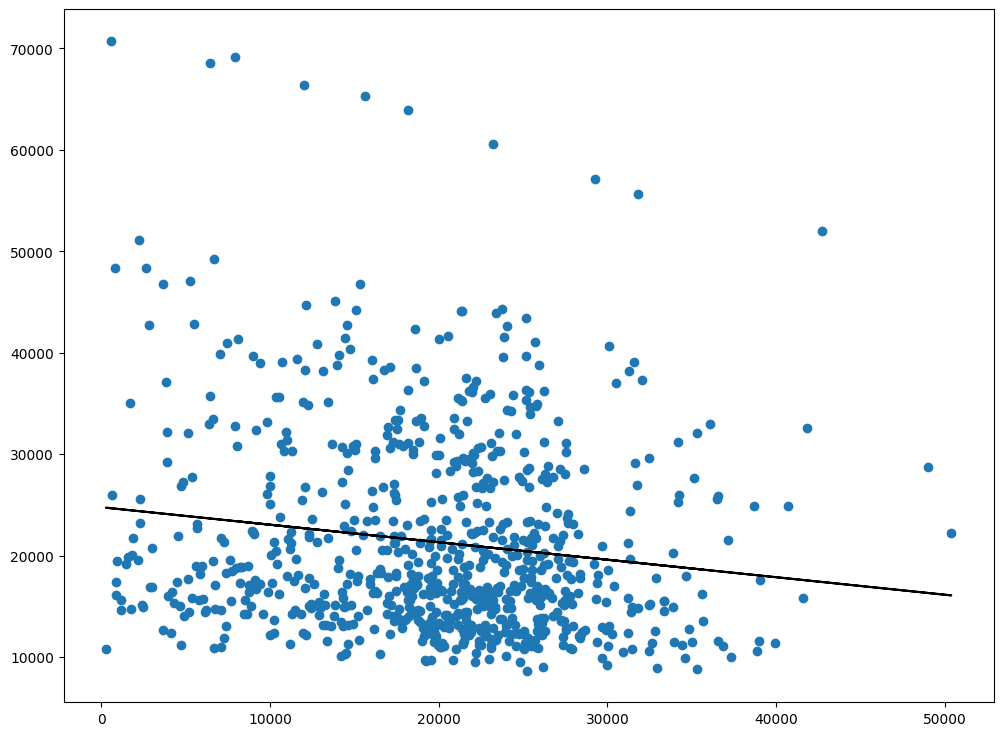

In [15]:
plt.figure(figsize=(12,9))
plt.plot(X, Y, 'o')
plt.plot(X, y_predict, 'k-')
plt.show()

<p>Несмотря на то, что зависимость от пробега наблюдаема, но она не столь существенна, чтобы эффективно описать данные, как видим на графике. Нужно что-то поумнее.</p>

In [16]:
# будем использовать набор данных, а не только пробег
X = data.loc[:, ['Mileage', 'Liter']]
X.head()

,Mileage,Liter
0,8221,3.1
1,9135,3.1
2,13196,3.1
3,16342,3.1
4,19832,3.1


In [18]:
Y = data.loc[:, ['Price']]
Y.head() # предсказываемая цена

,Price
0,17314.103129
1,17542.036083
2,16218.847862
3,16336.913140
4,16339.170324


In [19]:
model.fit(X, Y)
y_predict = model.predict(X) # обучаем регрессию

In [20]:
y_predict[:5]

array([[23512.66895659],
       [23366.40286625],
       [22716.52694409],
       [22213.0771408 ],
       [21654.57751796]])

In [ ]:
model.coef_

In [ ]:
model.intercept_

In [ ]:
8221 * -1.60028545e-01 + 3.1 * 4.96827812e+03 + model.intercept_

In [ ]:
np.sum(X.iloc[0].values * model.coef_) + model.intercept_

<p>Попробуем нарисовать как расходится факт с предсказаниями.</p>

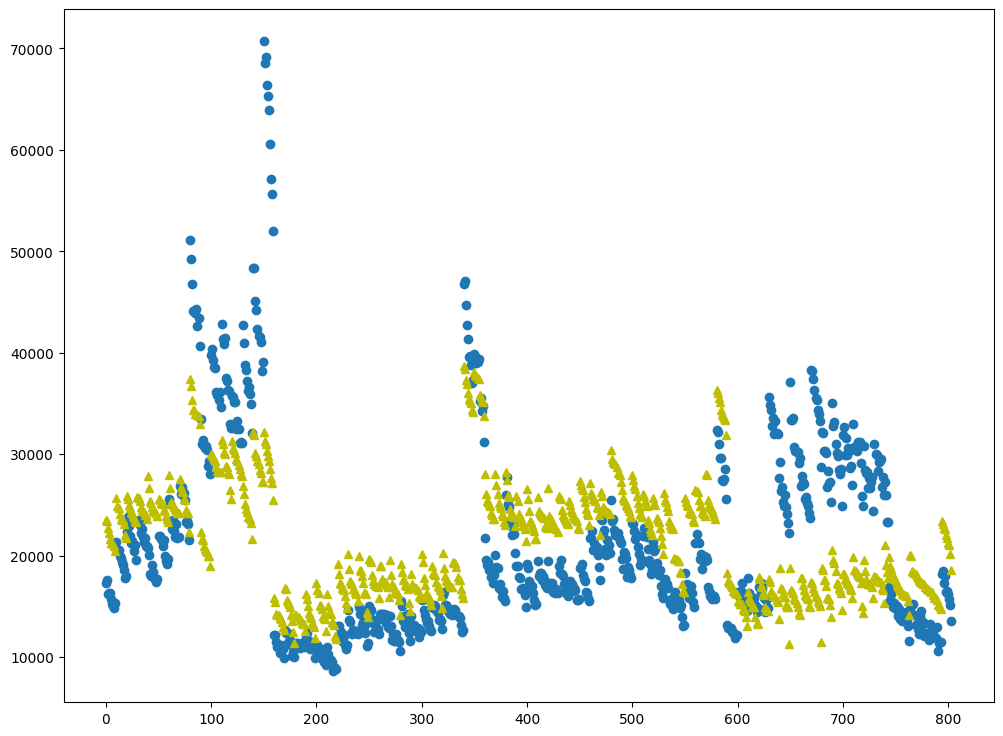

In [21]:
plt.figure(figsize=(12,9))
plt.plot(Y.index, Y, 'o')
plt.plot(Y.index, y_predict, 'y^')
plt.show() # видим как цена действительно накладывается на истину

In [25]:
test_obj = pd.DataFrame({
    'Mileage': [1],
    'Liter': [3],
})
test_obj.info()
model.predict(test_obj)

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Mileage  1 non-null      int64
 1   Liter    1 non-null      int64
dtypes: int64(2)
memory usage: 148.0 bytes


array([[24331.27578681]])

In [ ]:
test_obj

### Полиномиальная регрессия
<p id="4">Не всегда данные могут быть описаны (достаточно эффективно) линейной моделью. В некоторых задачах часто строятся полиномиальные модели. Здесь появляется дополнительный гиперпараметр - максимальная степень, в  которой могут находится параметры для описанния данных

#### Практика на собственном датасете.

 <p id="5">Сгенерируем свой собственный датасет для задачи полиномиальной регрессии.</p>

In [26]:
import numpy as np

from sklearn.metrics import r2_score # подгружаем метрику r2
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression # линейная регрессия

In [27]:
np.random.seed(0)
x = 2 - 3 * np.random.normal(0, 1, 20)
y = x - 2 * (x ** 2) + 0.5 * (x ** 3) + np.random.normal(-3, 3, 20) # заданы параметры при степенях

# преобразуем данный чтобы добавить новые оси
x = x[:, np.newaxis]
y = y[:, np.newaxis]
x.shape

(20, 1)

R2: 0.6386750054827146


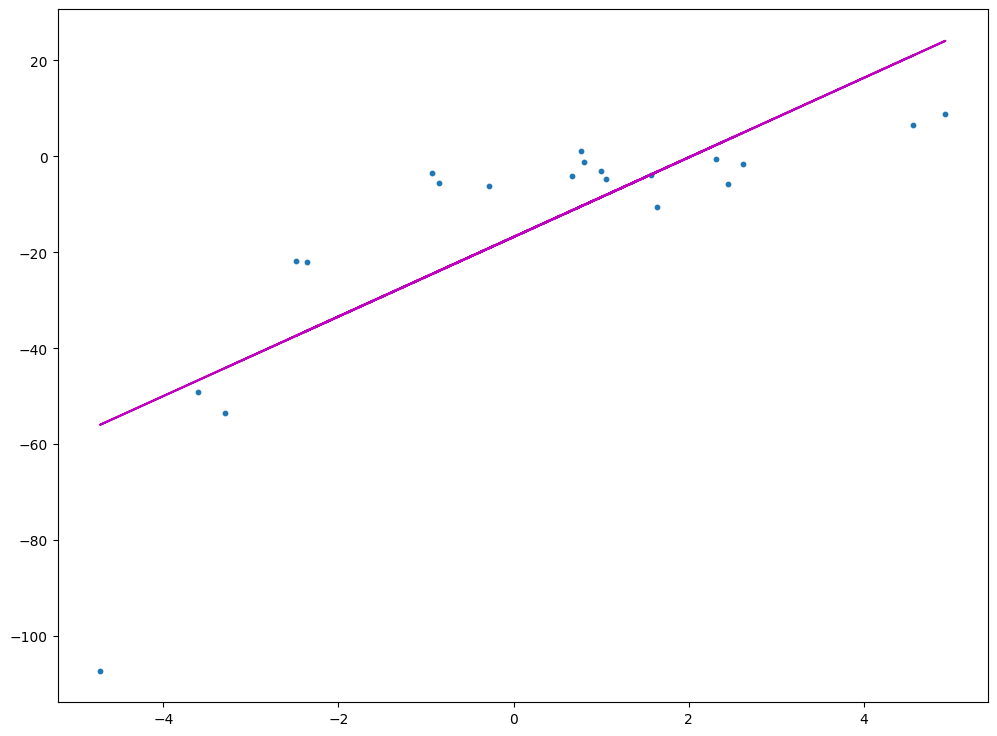

In [29]:
model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

# считаем метрику R2
r2 = model.score(x, y)
print('R2:', r2)


plt.figure(figsize=(12,9))
plt.scatter(x, y, s=10)

# рисуем наши смоделированные данные
# sort_axis = operator.itemgetter(0)
# sorted_zip = sorted(zip(x, y_pred), key=sort_axis)
# x_, y_pred = zip(*sorted_zip)

plt.plot(x, y_pred, color='m')
plt.show()

<p>Видим, что линейная модель описывает наши данные не очень хорошо. Это можно понять и по MSE, R2, и исходя из графика. Попробуем построить полиномиальную регрессию.</p>

In [ ]:
x

In [30]:
# sklearn генерирует допольнительное кол-во признаков для полиномиальной регресии
polynomial_features = PolynomialFeatures(degree=2) # указываем вторую степень полинома
x_poly = polynomial_features.fit_transform(x) # получаем новые признаки
x_poly

array([[ 1.        , -3.29215704, 10.83829796],
       [ 1.        ,  0.79952837,  0.63924562],
       [ 1.        , -0.93621395,  0.87649656],
       [ 1.        , -4.7226796 , 22.30370258],
       [ 1.        , -3.60267397, 12.97925974],
       [ 1.        ,  4.93183364, 24.32298305],
       [ 1.        , -0.85026525,  0.722951  ],
       [ 1.        ,  2.45407162,  6.02246754],
       [ 1.        ,  2.30965656,  5.3345134 ],
       [ 1.        ,  0.76820449,  0.59013814],
       [ 1.        ,  1.56786929,  2.4582141 ],
       [ 1.        , -2.36282052,  5.58292081],
       [ 1.        , -0.28311318,  0.08015307],
       [ 1.        ,  1.63497495,  2.67314309],
       [ 1.        ,  0.6684103 ,  0.44677233],
       [ 1.        ,  0.99897702,  0.99795508],
       [ 1.        , -2.48223722,  6.16150161],
       [ 1.        ,  2.61547479,  6.84070838],
       [ 1.        ,  1.0607969 ,  1.12529005],
       [ 1.        ,  4.56228722, 20.81446466]])

R2: 0.8537647164420812


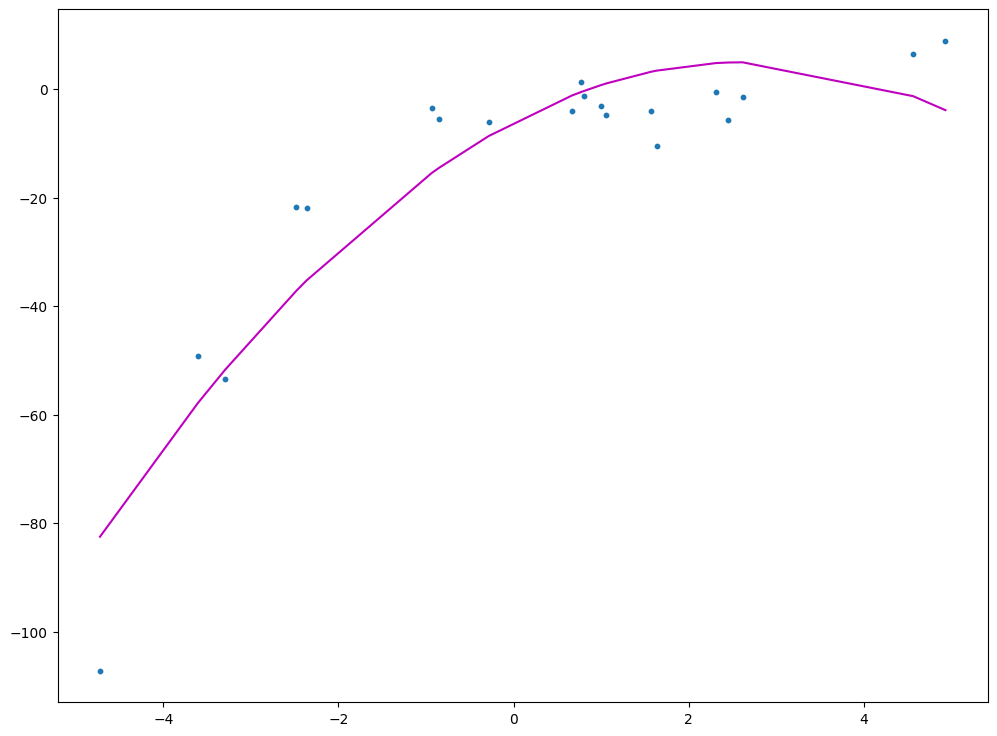

In [31]:
# теперь подаем эти признаки в линейную регресиию
# и проделаем все те же самые операции
model = LinearRegression()
model.fit(x_poly, y)
y_poly_pred = model.predict(x_poly)

r2 = model.score(x_poly, y)
print('R2:', r2)

plt.figure(figsize=(12,9))
plt.scatter(x, y, s=10)

sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x, y_poly_pred), key=sort_axis)
x_, y_poly_pred = zip(*sorted_zip)

plt.plot(x_, y_poly_pred, color='m')
plt.show()

<p>Проделаем то же самое, например, для 3 степени.</p>

R2: 0.9830071790386679


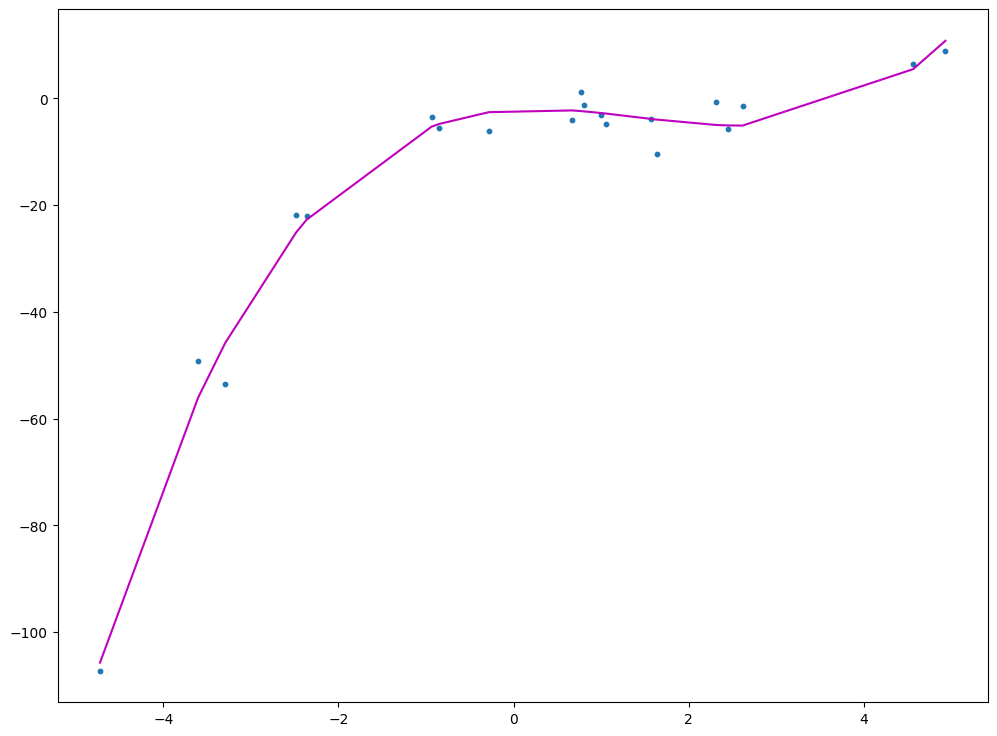

In [32]:
polynomial_features = PolynomialFeatures(degree=3)
x_poly = polynomial_features.fit_transform(x)

model = LinearRegression()
model.fit(x_poly, y)
y_poly_pred = model.predict(x_poly)

r2 = model.score(x_poly, y)
print('R2:', r2)

plt.figure(figsize=(12,9))
plt.scatter(x, y, s=10)

sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x, y_poly_pred), key=sort_axis)
x_, y_poly_pred = zip(*sorted_zip)

plt.plot(x_, y_poly_pred, color='m')
plt.show()

In [ ]:
x_poly

In [ ]:
model.coef_

In [ ]:
model.intercept_

In [ ]:
# y = x - 2 * (x ** 2) + 0.5 * (x ** 3) + np.random.normal(-3, 3, 20) # заданы параметры при степенях

<p>Видим что, с увелечением степени R2 поднялся до приемлемых значений, и наша модель достаточно хорошо описывается 3 степенью. Но стоит помнить, что чем больше мы задаем степень полинома, тем точнее полином будет накладываться на значения и модель будет переобучаться, поэтому с этим нужно быть осторожным. О переобучении речь будет идти в сл. уроках.</p>

<h2>Summary</h2>
<ol><li>Линейная регрессия лежит в основе многих сложных моделей, она позволяет очень эффективно предсказываать <b>общий тренд</b> данных, но также имеет и довольно <b>большие ограничения</b> на исследуемый датасет.</li><li>Полиномиальная регрессия умеет описывать <b>более сложные кривые</b> данных, которые не может описать линейная. <b>В зависимости от степени</b> полином будет описывать все точнее и точнее рассматриваемые данные, но не стоит забывать про <b>переобучение</b>.</li></ol>